In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
import numpy as np
import seaborn as sns
print("Done")

Done


In [2]:
# load dataset

train = pd.read_csv(
    "../data/raw/train.csv",
    dtype={"StateHoliday": "string"}
)

store = pd.read_csv("../data/raw/store.csv")

df = train.merge(store, on="Store", how= "left")

In [3]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [4]:
df.tail()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  str    
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  string 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  str    
 10  Assortment                 1017209 non-null  str    
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionOpenSinceYea

In [6]:
df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [7]:
# Checking missing values

df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

In [8]:
# Checking missing values percentage

(df.isnull().sum() / len(df)) * 100, 

(Store                         0.000000
 DayOfWeek                     0.000000
 Date                          0.000000
 Sales                         0.000000
 Customers                     0.000000
 Open                          0.000000
 Promo                         0.000000
 StateHoliday                  0.000000
 SchoolHoliday                 0.000000
 StoreType                     0.000000
 Assortment                    0.000000
 CompetitionDistance           0.259730
 CompetitionOpenSinceMonth    31.787764
 CompetitionOpenSinceYear     31.787764
 Promo2                        0.000000
 Promo2SinceWeek              49.943620
 Promo2SinceYear              49.943620
 PromoInterval                49.943620
 dtype: float64,)

In [9]:
# Check for duplicated rows

df.duplicated().sum()

np.int64(0)

In [10]:
# Change Column Date to date format

df["Date"] = pd.to_datetime(df["Date"])

In [11]:
# Verify

df["Date"].dtype

dtype('<M8[us]')

### __Sales Distributions__

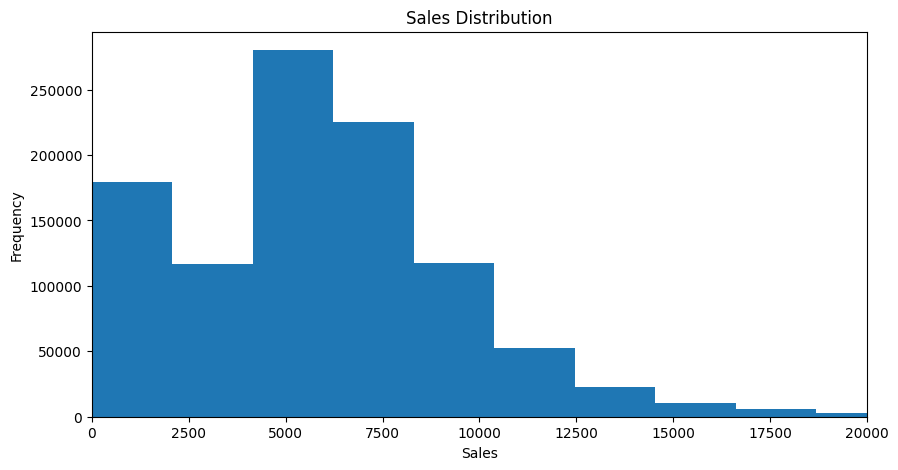

In [12]:
# Plot of sales distributions

plt.figure(figsize=(10,5))
plt.hist(df["Sales"], bins = 20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.xlim(0,20000)

plt.show()

In [13]:
# Inspect data skewness

df["Sales"].skew()

np.float64(0.6414596158103795)

### __Sales Distribution Interpretation__

This Histogram shows the distribution if sales across all stores and dates in the Rossmann dataset.
Most values are concentrated between 4000 and 8000, indicating that the majority of stores generate moderate daily sales. As sales increase beyond 10.000, the frequency decreases significantly, meaning very high sales days are relativetly rare.
The distribution is positively skewed (right-skewed), which is confirmed by the skewness value of approximately 0.64.This indicates that while most observations fall withiin moderate sales range, a smaller group of observations contain exceptionally high value sales.
the long right tail may be influenced by factor such has promotions, holydays, seasonal demand or high performing stores. Additionally, the visible concentration near zero sales suggests the presence of closed-store days, which is coommoun in ratail forecasting datasets.
this analysis is important because it reveals that sales are not normally distributed. As a result, machine learning such as XGboost, lightGMB or Random Forest may perform better than traditional linear models for forecasting tasks.

In [14]:
# Count how many rows have zero sales

(df["Sales"] == 0).sum()

np.int64(172871)

### Observation

The dataset contains 172,871 observations with zero sales values. This likely corresponds to days when stores were closed, rather than poor sales performance. These records should be carefully handled, since including closed-store days may negatively affect forecasting accuracy and bias model predictions downward.

In [15]:
# Create a filtered dataframe just with the days the stores were open.
df_open = df[df["Open"] == 1]

In [16]:
df_open.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,844392.000000,844392.000000,844392,844392.000000,844392.000000,844392.0,844392.000000,844392.000000,842206.000000,575773.000000,575773.000000,844392.000000,421085.000000,421085.000000
mean,558.422920,3.520361,2014-04-11 01:02:42.487564,6955.514291,762.728395,1.0,0.446352,0.193580,5457.979627,7.224879,2008.697747,0.498684,23.253426,2011.754019
min,1.000000,1.000000,2013-01-01 00:00:00,0.000000,0.000000,1.0,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2320.000000,8.000000,2010.000000,0.000000,22.000000,2012.000000
75%,837.000000,5.000000,2014-12-10 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6890.000000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000
std,321.731914,1.723689,NaN,3104.214680,401.227674,0.0,0.497114,0.395103,7809.437311,3.210144,5.978048,0.499999,14.100569,1.660962


In [17]:
df_open.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  string        
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  str           
 10  Assortment                 844392 non-null  str           
 11  CompetitionDistance        842206 non-null  float64       
 12  Com

In [18]:
# Check how many rows were the stores open but still have zero sales.
(df_open["Sales"] == 0).sum()

np.int64(54)

#### __Observation__

There are 54 observations in the dataset where stores were marked as open but still recorded zero sales. These records are likely anomalies or data inconsistencies and may negatively affect forecasting performance. Therefore, they were removed to ensure cleaner sales behavior for model training and analysis.

In [19]:
df_open = df_open[df_open["Sales"]> 0]

In [20]:
df_open.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,844338.000000,844338.000000,844338,844338.000000,844338.000000,844338.0,844338.000000,844338.000000,842152.000000,575738.000000,575738.000000,844338.000000,421046.000000,421046.000000
mean,558.421374,3.520350,2014-04-11 01:08:38.729703,6955.959134,762.777166,1.0,0.446356,0.193578,5458.156627,7.224842,2008.697753,0.498670,23.254177,2011.753929
min,1.000000,1.000000,2013-01-01 00:00:00,46.000000,8.000000,1.0,0.000000,0.000000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,280.000000,2.000000,2013-08-16 00:00:00,4859.000000,519.000000,1.0,0.000000,0.000000,710.000000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.000000,3.000000,2014-03-31 00:00:00,6369.000000,676.000000,1.0,0.000000,0.000000,2320.000000,8.000000,2010.000000,0.000000,22.000000,2012.000000
75%,837.000000,5.000000,2014-12-11 00:00:00,8360.000000,893.000000,1.0,1.000000,0.000000,6890.000000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.000000,7.000000,2015-07-31 00:00:00,41551.000000,7388.000000,1.0,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000
std,321.730861,1.723712,NaN,3103.815515,401.194153,0.0,0.497114,0.395102,7809.573181,3.210118,5.978064,0.499999,14.100647,1.660946


## __Promo Impact On Sales__

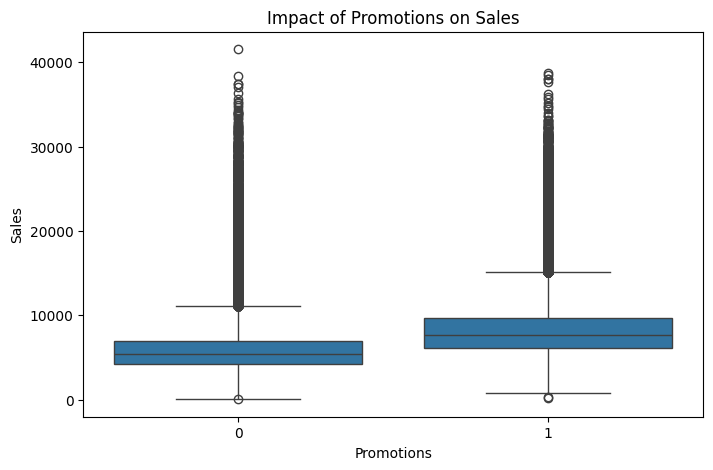

In [21]:
# Create Boxplot to visualy analyze the impact that promo has on sales (short-term active promotions)
plt.figure(figsize=(8,5))

sns.boxplot(x = "Promo",y = "Sales", data= df_open)
plt.title("Impact of Promotions on Sales")
plt.xlabel("Promotions")
plt.ylabel("Sales")
plt.show()

In [22]:
# Numerical value of impact of promotions on sales
df_open.groupby("Promo")["Sales"].mean()

Promo
0    5929.826183
1    8228.739731
Name: Sales, dtype: float64

#### __Observation__

The boxplot and numerical analysis indicate that promotions have a significant positive impact on sales performance. Stores running promotions (`Promo = 1`) achieved a higher average sales value (~8,229) compared to stores without promotions (`Promo = 0`), which averaged approximately 5,929 in sales.

Additionally, the median sales and overall distribution are visibly higher during promotional periods, suggesting that promotions consistently increase customer purchasing activity. Both groups contain several high-value outliers, indicating occasional spikes in sales, likely driven by seasonal demand, holidays, or highly successful promotional campaigns.

These findings confirm that the `Promo` feature is likely to be an important predictor in the forecasting model.



## __Promo2 impact on sales__

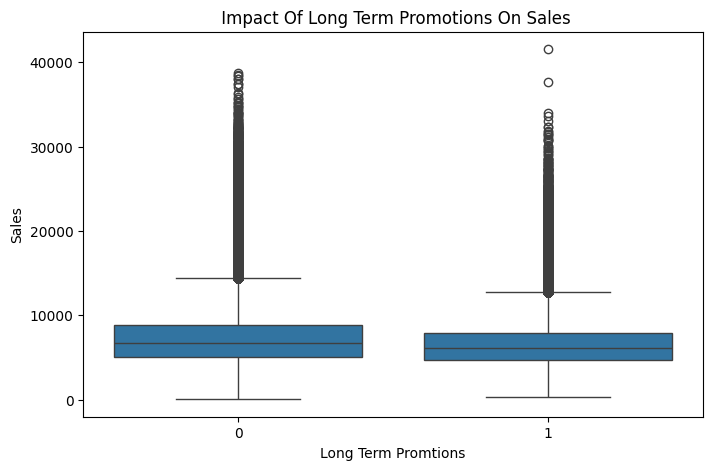

In [23]:
# Create Boxplot to visualy analyze the impact that Promo2 has on sales(these are long-term/recurring promotions)

plt.figure(figsize=(8,5))

sns.boxplot( x = "Promo2", y = "Sales", data = df_open)
plt.title(" Impact Of Long Term Promotions On Sales")
plt.xlabel("Long Term Promtions")
plt.ylabel("Sales")
plt.show()


In [24]:
# Numerical values of impact of long-term promotions on sales
df_open.groupby("Promo2")["Sales"].mean()

Promo2
0    7350.818414
1    6558.993542
Name: Sales, dtype: float64

#### __Observation__

The boxplot indicates that long-term recurring promotions (`Promo2`) do not have as strong an impact on sales as short-term active promotions (`Promo`). The distributions overlap considerably, and the median sales values remain relatively close between both groups.

Additionally, the average sales for stores participating in `Promo2` (~6,559) are lower than the average sales for stores not participating in recurring promotions (~7,350). However, this does not necessarily imply that long-term promotions reduce sales performance.

One possible explanation is that lower-performing or struggling stores may rely more heavily on recurring promotional campaigns to maintain customer activity. This suggests that the relationship between `Promo2` and sales may depend on additional factors such as store type, customer behavior, seasonality, or promotional timing.


## __Number of Customers Impact on sales__

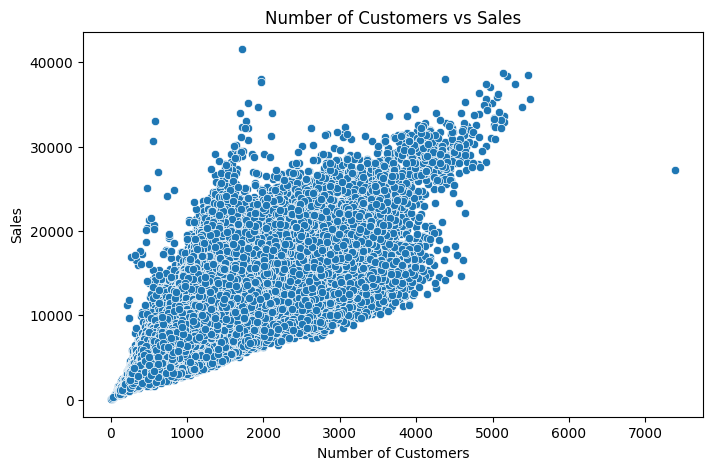

In [25]:
# Scatterplot to visually analyze how number of customers influence sales

plt.figure(figsize=(8,5))

sns.scatterplot(x = "Customers", y = "Sales", data = df_open)
plt.title("Number of Customers vs Sales")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")

plt.show()

In [26]:
# Custumer grouping into bins
#Numerical values of impact if number of customers(binned) on sales

df_open["CustomerGroup"] = pd.cut(
    df_open["Customers"],
    bins=range(0, 8000, 500)
)

df_open.groupby("CustomerGroup")["Sales"].mean()

CustomerGroup
(0, 500]         4093.843558
(500, 1000]      6757.085061
(1000, 1500]    10143.462065
(1500, 2000]    13135.602303
(2000, 2500]    15761.195732
(2500, 3000]    16291.062262
(3000, 3500]    18015.188765
(3500, 4000]    20012.895522
(4000, 4500]    25309.099567
(4500, 5000]    29888.779412
(5000, 5500]    34672.555556
(7000, 7500]    27190.000000
Name: Sales, dtype: float64

#### __Observation__

The scatterplot and grouped customer analysis reveal a strong positive relationship between the number of customers visiting a store and total sales performance. As customer traffic increases, sales value also increase signifficantly, indicating that customer count is one of the strongest drivers of revenue in the dataset.
The grouped average sales analysis further confirms this trend, with higher customer intervals generally corresponding to higher average sales values. However, some irregularities appear in the higher customer ranges (above approximatelly 5,500 customers), where the relationship becomes less stable. One possible explanation could be seasonal shopping behavior, holydays, store-specific charracteristics, or other external business factors influencing purchasing patterns.
Overall, the "Customers" feature appears to be one of the most important predictors for the forecasting model due to its steong relationship with sales activity.


In [27]:
# Drop the CustomerGroup column created for EDA purpose only
df_open = df_open.drop(columns = ["CustomerGroup"])

In [28]:
## __SchoolHolydays Impact On Sales__


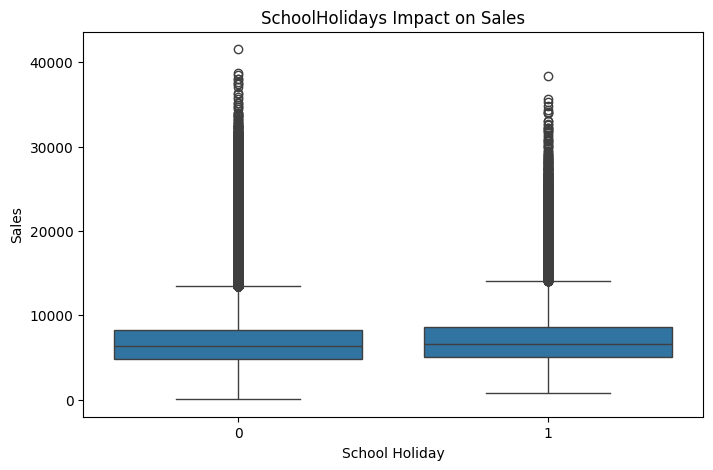

In [29]:
# Plot to visually analyze how the "SchoolHoliday" influence Sales Volume

plt.figure(figsize=(8,5))

sns.boxplot(x = "SchoolHoliday", y = "Sales", data = df_open)
plt.title("SchoolHolidays Impact on Sales")
plt.xlabel("School Holiday")
plt.ylabel("Sales")

plt.show()

In [30]:
# Numerical values of impact of school holidays on sales
df_open.groupby("SchoolHoliday")["Sales"].mean()

SchoolHoliday
0    6897.207830
1    7200.710282
Name: Sales, dtype: float64

#### __Observation__

The boxplot indicates a moderate difference in sales performance between regular school days and school holiday periods. Although both distributions overlap considerably,stores tend to record slightly higher sales values during school holidays.
The numerical analysis confirms this observation, showing an average sales value of approximately 7,200 during school holidays compared to approximately 6,900 during regular school periods.
This suggests that school holidays may positively influence customer activity and purchasing behavior, likely due to increased free time and family-related shopping activity.
While the effect is not extremely large, this feature remains valiable for for forecasting because school holidays represent a recurring seasonal pattern that can help models capture temporal changes in demand behavior.



## __StateHoliday Impact On Sales__





In [31]:
# Check categorical values
df_open["StateHoliday"].unique()

<StringArray>
['0', 'a', 'b', 'c']
Length: 4, dtype: string

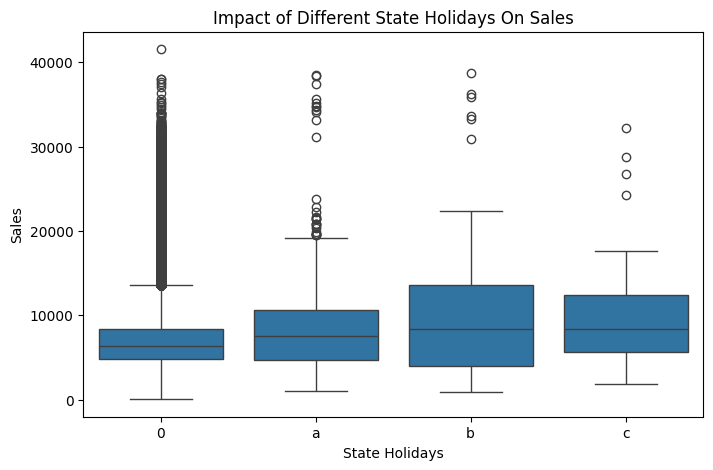

In [32]:
# How does StateHoliday Impact sales in each categorie?


plt.figure(figsize=(8,5))

sns.boxplot(x = "StateHoliday",y = "Sales", data = df_open)
plt.title("Impact of Different State Holidays On Sales")
plt.xlabel("State Holidays")
plt.ylabel("Sales")

plt.show()

           

In [33]:
# Numerical values of impact of the different holidays on sales
df_open.groupby("StateHoliday")["Sales"].mean()

StateHoliday
0    6953.960229
a    8487.471182
b    9887.889655
c    9743.746479
Name: Sales, dtype: float64

#### __Observation__

After looking up the encoded data in the documentation of this particular dataset, wwe conclude the variables meanning are:
0) Non-holiday
a) State holiday
b)Easter holiday
c)Christmas holiday
In the Boxplot becomes apparent that all holiday categories positively impact sales, with Easter and Christmas showing stronger effects.
The higher median sales visible in the boxplot are Easter and Christmas,followed by State holiday. Also both Easter and Christmas show stronger upper quartile behavior.
Holidays periods exhibit larger sales dispersion and more high-end outliers,suggesting increased volatility in customer purchasing behavior during these events.
when analyzing the numerical values it confirms that Easter (b) is the highest avarage sales holidays value approximately 9.890 of average sales followed by Christmas (c) approximately 9,750, followed by (a) State holiday approximately 6,950. This feature has great value for our forecasting model either as it is or by creating separated features for each holiday and droping the original column (Feature Engeneering Notebook) so the data does not become bias to the trained model.
This variable is expected to have a meaningful predictive power because holiday events systematically alter customer demand patterns and recur consistently over time.

## __DayOfWeek Impact On Sales__

In [34]:
# Variable categorical values 
df_open["DayOfWeek"].unique()

array([5, 4, 3, 2, 1, 7, 6])

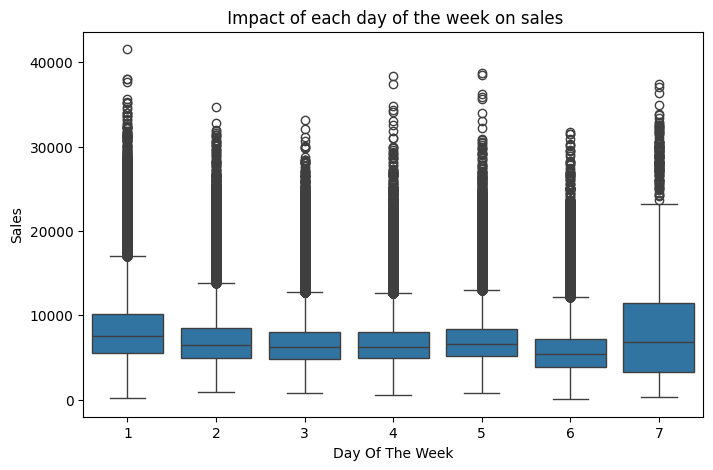

In [35]:
# Plot to visually analyze  the impact of each day of the week on sales

plt.figure(figsize=(8,5))

sns.boxplot(x = "DayOfWeek", y = "Sales", data = df_open)
plt.title(" Impact of each day of the week on sales")
plt.xlabel("Day Of The Week")
plt.ylabel("Sales")

plt.show()


In [36]:
# Numerical values of of impact of week day on sales 
df_open.groupby("DayOfWeek")["Sales"]\
    .mean()\
    .sort_values(ascending=False)


DayOfWeek
7    8224.723908
1    8216.252259
2    7088.409086
5    7073.034133
4    6768.214973
3    6728.786679
6    5875.084935
Name: Sales, dtype: float64

In [37]:
# Counts of how many stores are open on each day of the week
df_open["DayOfWeek"].value_counts().sort_index()

DayOfWeek
1    137557
2    143955
3    141922
4    134626
5    138633
6    144052
7      3593
Name: count, dtype: int64

### Observation

According to the dataset documentation, the `DayOfWeek` variable is encoded as:

1 - Monday  
2 - Tuesday  
3 - Wednesday  
4 - Thursday  
5 - Friday  
6 - Saturday  
7 - Sunday  

The boxplot indicates that Sunday (7) and Monday (1) exhibit the highest median sales distributions among all weekdays. These two days also display broader sales dispersion and a larger concentration of upper-tail outliers, suggesting increased variability in customer purchasing behavior during these periods.

Additionally, Sunday and Monday show wider interquartile ranges compared to the remaining weekdays, indicating stronger high-end sales activity. In contrast, Saturday (6) presents the lowest median and average sales values, as well as fewer extreme outliers.

Grouped mean sales confirm that Sunday (7) has the highest observed average sales value at approximately 8,225, followed closely by Monday (1) at approximately 8,216. Saturday (6) records the lowest average sales value at approximately 5,875.

However, further inspection of the dataset reveals that Sunday contains substantially fewer observations compared to the remaining weekdays. This suggests that most stores are closed on Sundays, and only a limited subset of stores remains operational. Consequently, the elevated Sunday sales statistics are likely influenced by selective store openings rather than representing overall weekly purchasing behavior.

Overall, the analysis suggests that customer purchasing behavior varies systematically throughout the week, making `DayOfWeek` a potentially valuable predictive feature for the forecasting model.

## __EDA Conclusion__

The Exploratory data analysis identified several variables exhibiting meaningful relationships with sales performance, including customer volume, promotional campaigns,holyday indicators, and weekly purchasing patterns. These findings suggest that the analyzed features contain predictive signal relevant to the forecasting task.
Not all the variables were explored exhaustively during EDA phase, as primary objective was to identify the most influencial drivers of sales behavior and detect potential data quality or structural issues.
Additional variables and temporal information will be further transformed and engineered in the Feature Engineering notebook inn order to better capture seasonality, promotional dynamics, competition effects, and other forecasting-related patterns required for predictive modelling

In [38]:
# creation of database that will be used in Feature Engineering
# This dataset is saved in the folder data/processed

# df_open.to_csv("Processed_data.csv", index = False)